In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv.gz"
df = pd.read_csv(url, sep=";")
df.head()


HTTPError: HTTP Error 404: Not Found

In [1]:
df.shape
df["quality"].value_counts().sort_index()

NameError: name 'df' is not defined

In [5]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
df.shape
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [7]:
import numpy as np

X = df.drop(columns=["quality"])
y = (df["quality"] >= 7).astype(int)

print(f"Features: {X.shape[1]}")
print(f"Good wines: {y.sum()} / {len(y)} ({y.mean():.1%})")

Features: 11
Good wines: 217 / 1599 (13.6%)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 score: {f1_score(y_test, y_pred):.3f}")

Accuracy: 0.944
F1 score: 0.750


In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring="f1")

print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.3f}")
print(f"Std dev: {scores.std():.3f}")

F1 scores per fold: [0.23529412 0.37777778 0.28571429 0.48275862 0.31034483]
Mean F1: 0.338
Std dev: 0.086


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")
    print(f"{name:22s}  F1: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression     F1: 0.390 ± 0.106
Random Forest           F1: 0.384 ± 0.104
Gradient Boosting       F1: 0.403 ± 0.073


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,        # use all CPU cores
)

grid.fit(X, y)

print(f"Best F1: {grid.best_score_:.3f}")
print(f"Best params: {grid.best_params_}")

Best F1: 0.386
Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "n_estimators": randint(50, 500),
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist,
    n_iter=30,           # try 30 random combos
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X, y)
print(f"Best F1: {random_search.best_score_:.3f}")
print(f"Best params: {random_search.best_params_}")

Best F1: 0.374
Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 363}


In [13]:
# 1. Set aside a final test set, untouched
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Do all your CV / tuning on X_train only
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

# 3. Evaluate the best model on the test set, exactly once
final_model = grid.best_estimator_
test_score = f1_score(y_test, final_model.predict(X_test))

print(f"CV F1 (training data): {grid.best_score_:.3f}")
print(f"Test F1 (held out):    {test_score:.3f}")

CV F1 (training data): 0.521
Test F1 (held out):    0.694


              precision    recall  f1-score   support

    Not good       0.94      0.99      0.96       277
        Good       0.86      0.58      0.69        43

    accuracy                           0.93       320
   macro avg       0.90      0.78      0.83       320
weighted avg       0.93      0.93      0.93       320



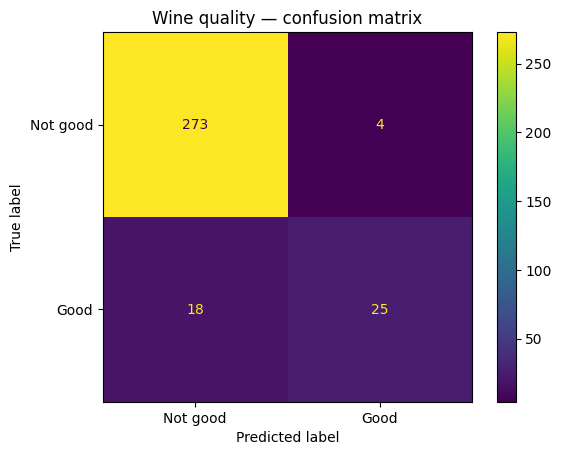

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Not good", "Good"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Not good", "Good"]).plot()
plt.title("Wine quality — confusion matrix")
plt.show()

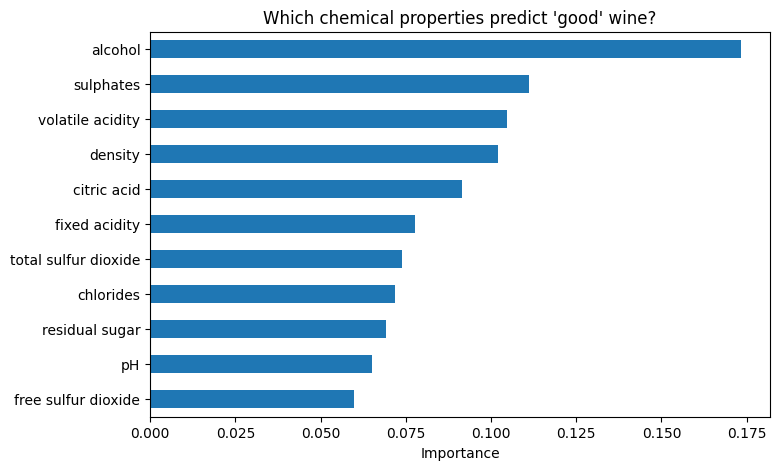

In [15]:
importances = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values()

importances.plot(kind="barh", figsize=(8, 5))
plt.title("Which chemical properties predict 'good' wine?")
plt.xlabel("Importance")
plt.show()